# India AQI Forecasting — Pre-Baseline Preparation
**MSE 546 — Group 2**

This notebook resolves all open questions from the EDA before implementing the baseline:
1. Missing-data strategy (imputation justification + execution)
2. Scope clarification (all 26 cities, city as a feature)
3. Target-variable transformation (raw vs log AQI)
4. Temporal train/test split (no leakage)
5. Feature engineering (lags, rolling stats, calendar, city encoding)
6. Metric selection (RMSE, MAE, R², per-category breakdown)
7. O3 sign-flip handling (city-aware feature behaviour)
8. Baseline model (Ridge regression)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

PATH = 'city_day.csv'
df = pd.read_csv(PATH)
df.columns = [c.lower() for c in df.columns]
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df = df.sort_values(['city', 'date']).reset_index(drop=True)

print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} cols')
print(f'Cities: {df["city"].nunique()} | Date range: {df["date"].min().date()} -> {df["date"].max().date()}')
print(f'Total missing values: {df.isna().sum().sum():,}')

Shape: 29,531 rows x 16 cols
Cities: 26 | Date range: 2015-01-01 -> 2020-07-01
Total missing values: 88,488


---
## 1. Scope Clarification

**Decision:** The target is all 26 Indian cities. `city` becomes a categorical feature (one-hot encoded).
This is an **all-India regression** problem — we predict AQI for any city on any day.
City identity captures baseline pollution levels; temporal + pollutant features capture day-to-day variation.

In [2]:
# Confirm scope: all cities, show row distribution
city_counts = df.groupby('city').agg(
    rows=('date', 'count'),
    aqi_available=('aqi', 'count'),
    aqi_pct=('aqi', lambda x: x.notna().mean() * 100),
    date_min=('date', 'min'),
    date_max=('date', 'max')
).round(1)
print(city_counts.to_string())
print(f'\nCities with >80% AQI coverage: {(city_counts["aqi_pct"] > 80).sum()}')
print(f'Cities with <50% AQI coverage: {(city_counts["aqi_pct"] < 50).sum()}')

                    rows  aqi_available  aqi_pct   date_min   date_max
city                                                                  
Ahmedabad           2009           1334     66.4 2015-01-01 2020-07-01
Aizawl               113            111     98.2 2020-03-11 2020-07-01
Amaravati            951            841     88.4 2017-11-24 2020-07-01
Amritsar            1221           1126     92.2 2017-02-27 2020-07-01
Bengaluru           2009           1910     95.1 2015-01-01 2020-07-01
Bhopal               289            278     96.2 2019-09-17 2020-07-01
Brajrajnagar         938            713     76.0 2017-12-07 2020-07-01
Chandigarh           304            299     98.4 2019-09-02 2020-07-01
Chennai             2009           1884     93.8 2015-01-01 2020-07-01
Coimbatore           386            344     89.1 2019-06-12 2020-07-01
Delhi               2009           1999     99.5 2015-01-01 2020-07-01
Ernakulam            162            153     94.4 2020-01-22 2020-07-01
Gurugr

---
## 2. Missing Data Strategy

**Goal:** Understand *why* data is missing (random vs systematic) before choosing a fill strategy.

**Decision rationale:**
- Missingness is city-dependent (some cities have shorter monitoring histories or sparser sensors).
- Per-city median imputation preserves each city's pollution baseline and is robust to the heavy right skew.
- Rows where AQI itself is missing are **dropped** — we cannot train or evaluate on unknown targets.
- A binary `_missing` flag is added for each pollutant so the model can learn when a sensor was offline.

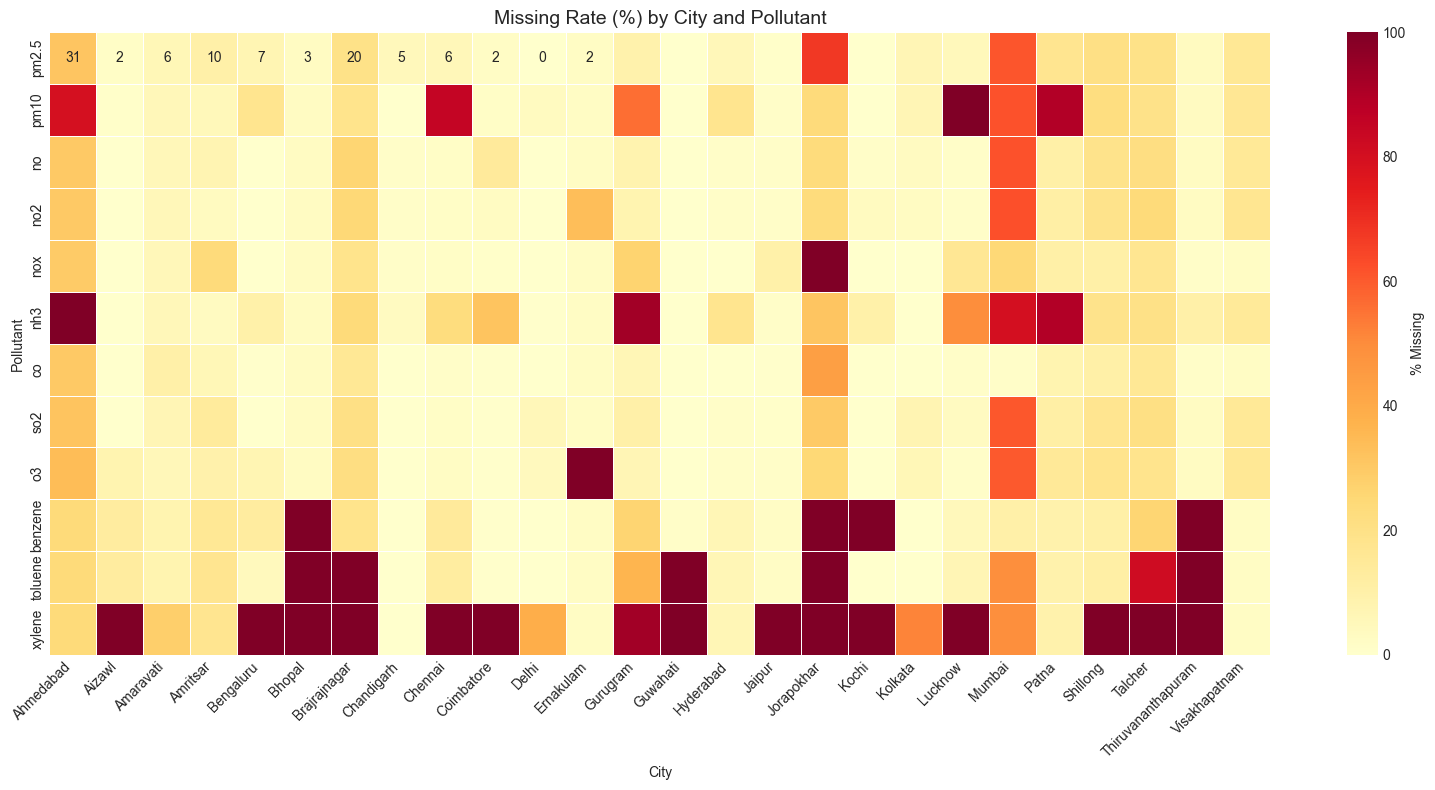


Overall missing rate per pollutant:
xylene     61.3%
pm10       37.7%
nh3        35.0%
toluene    27.2%
benzene    19.0%
pm2.5      15.6%
nox        14.2%
o3         13.6%
so2        13.1%
no2        12.1%
no         12.1%
co          7.0%
dtype: object


In [3]:
# --- 2a: Visualise missing-rate by city and pollutant ---
pollutant_cols = ['pm2.5', 'pm10', 'no', 'no2', 'nox', 'nh3', 'co', 'so2', 'o3',
                  'benzene', 'toluene', 'xylene']

miss_rate = df.groupby('city')[pollutant_cols].apply(lambda x: x.isna().mean() * 100)

fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(miss_rate.T, cmap='YlOrRd', annot=True, fmt='.0f', linewidths=0.5,
            cbar_kws={'label': '% Missing'}, ax=ax)
ax.set_title('Missing Rate (%) by City and Pollutant', fontsize=14)
ax.set_xlabel('City')
ax.set_ylabel('Pollutant')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Print summary
print('\nOverall missing rate per pollutant:')
print(df[pollutant_cols].isna().mean().sort_values(ascending=False).map('{:.1%}'.format))

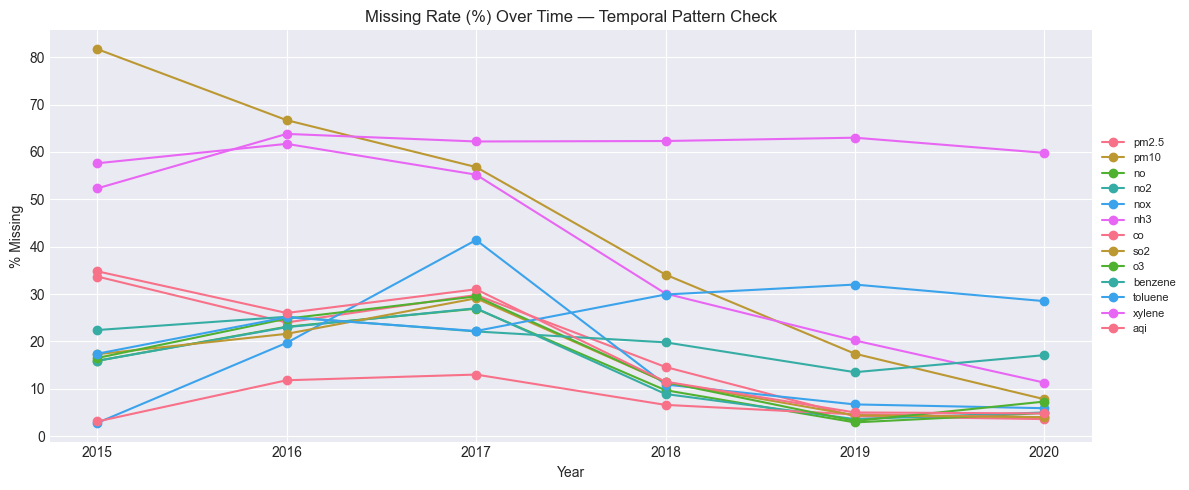

In [4]:
# --- 2b: Check if missingness is temporal (e.g. early years have more gaps) ---
df['year'] = df['date'].dt.year
miss_by_year = df.groupby('year')[pollutant_cols + ['aqi']].apply(
    lambda x: x.isna().mean() * 100
).round(1)

fig, ax = plt.subplots(figsize=(12, 5))
miss_by_year.plot(ax=ax, marker='o', linewidth=1.5)
ax.set_title('Missing Rate (%) Over Time — Temporal Pattern Check')
ax.set_ylabel('% Missing')
ax.set_xlabel('Year')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8)
plt.tight_layout()
plt.show()

In [5]:
# --- 2c: Execute imputation strategy ---

# Step 1: Drop rows where target (AQI) is missing — cannot use these for training or evaluation
print(f'Rows before AQI dropna: {len(df):,}')
df = df.dropna(subset=['aqi']).reset_index(drop=True)
print(f'Rows after AQI dropna:  {len(df):,}  (dropped {29531 - len(df):,} rows)')

# Step 2: Add binary missingness flags before imputing
for col in pollutant_cols:
    df[f'{col}_missing'] = df[col].isna().astype(int)

# Step 3: Per-city median imputation for pollutants
for col in pollutant_cols:
    city_medians = df.groupby('city')[col].transform('median')
    df[col] = df[col].fillna(city_medians)

# Verify no missing pollutant values remain
print(f'\nRemaining missing values after imputation:')
print(df[pollutant_cols].isna().sum())
print(f'\nMissingness flag columns created: {[c for c in df.columns if c.endswith("_missing")]}')

Rows before AQI dropna: 29,531
Rows after AQI dropna:  24,850  (dropped 4,681 rows)

Remaining missing values after imputation:
pm2.5          0
pm10        1893
no             0
no2            0
nox          771
nh3         1334
co             0
so2            0
o3           153
benzene     2259
toluene     4084
xylene     12381
dtype: int64

Missingness flag columns created: ['pm2.5_missing', 'pm10_missing', 'no_missing', 'no2_missing', 'nox_missing', 'nh3_missing', 'co_missing', 'so2_missing', 'o3_missing', 'benzene_missing', 'toluene_missing', 'xylene_missing']


---
## 3. Target Variable: Raw vs Log AQI

AQI is heavily right-skewed. We compare predicting raw AQI vs log1p(AQI).
log1p is preferred if it tightens the residual distribution and improves low-AQI prediction.

**We will train on log1p(AQI) and evaluate on the original scale** (expm1 to invert).
This is standard practice for skewed regression targets.

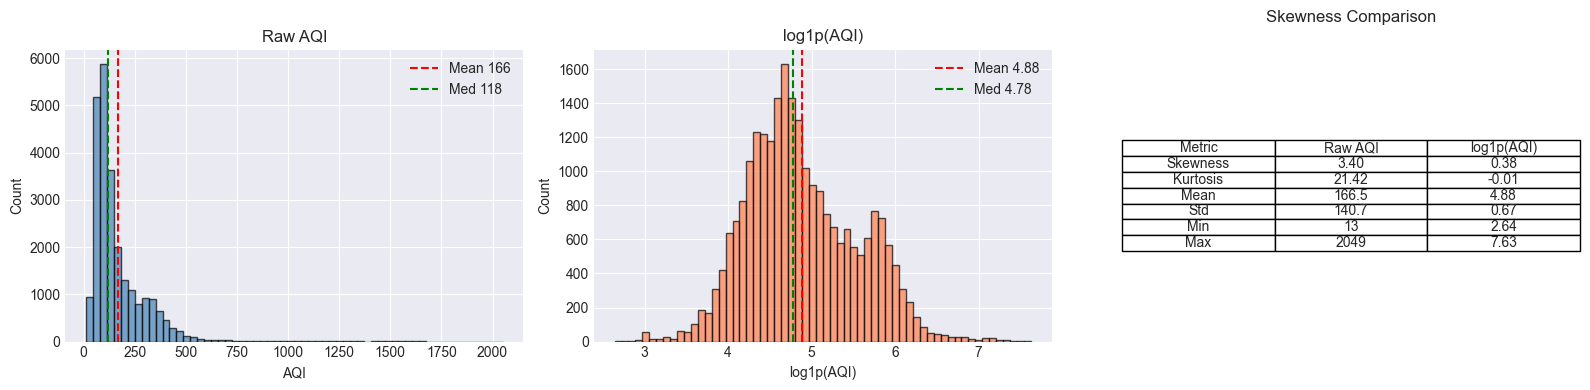


Decision: Train on log1p(AQI). Skewness drops from 3.40 to 0.38.


In [6]:
# Compare distributions
df['aqi_log'] = np.log1p(df['aqi'])

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Raw
axes[0].hist(df['aqi'], bins=60, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(df['aqi'].mean(), color='red', ls='--', label=f'Mean {df["aqi"].mean():.0f}')
axes[0].axvline(df['aqi'].median(), color='green', ls='--', label=f'Med {df["aqi"].median():.0f}')
axes[0].set(title='Raw AQI', xlabel='AQI', ylabel='Count')
axes[0].legend()

# Log
axes[1].hist(df['aqi_log'], bins=60, color='coral', edgecolor='black', alpha=0.7)
axes[1].axvline(df['aqi_log'].mean(), color='red', ls='--', label=f'Mean {df["aqi_log"].mean():.2f}')
axes[1].axvline(df['aqi_log'].median(), color='green', ls='--', label=f'Med {df["aqi_log"].median():.2f}')
axes[1].set(title='log1p(AQI)', xlabel='log1p(AQI)', ylabel='Count')
axes[1].legend()

# QQ-style: skewness comparison
from scipy.stats import skew, kurtosis
stats_table = pd.DataFrame({
    'Metric': ['Skewness', 'Kurtosis', 'Mean', 'Std', 'Min', 'Max'],
    'Raw AQI': [f'{skew(df["aqi"]):.2f}', f'{kurtosis(df["aqi"]):.2f}',
                f'{df["aqi"].mean():.1f}', f'{df["aqi"].std():.1f}',
                f'{df["aqi"].min():.0f}', f'{df["aqi"].max():.0f}'],
    'log1p(AQI)': [f'{skew(df["aqi_log"]):.2f}', f'{kurtosis(df["aqi_log"]):.2f}',
                   f'{df["aqi_log"].mean():.2f}', f'{df["aqi_log"].std():.2f}',
                   f'{df["aqi_log"].min():.2f}', f'{df["aqi_log"].max():.2f}']
})
axes[2].axis('off')
axes[2].table(cellText=stats_table.values, colLabels=stats_table.columns,
              loc='center', cellLoc='center').auto_set_font_size(False)
axes[2].set_title('Skewness Comparison', pad=20)

plt.tight_layout()
plt.show()

print(f'\nDecision: Train on log1p(AQI). Skewness drops from {skew(df["aqi"]):.2f} to {skew(df["aqi_log"]):.2f}.')

---
## 4. Temporal Train / Test Split

**No random splitting.** AQI is temporally autocorrelated — a random split leaks future information.

**Strategy:** Use a cutoff date. Everything before = train, everything after = test.
We target ~80/20 split by row count. We verify the split visually and confirm no city disappears entirely from either set.

In [7]:
# Find the cutoff date that gives ~80% train
df_sorted = df.sort_values('date')
n = len(df_sorted)
target_split_idx = int(n * 0.80)
cutoff_date = df_sorted.iloc[target_split_idx]['date']
# Round to month boundary for cleanliness
cutoff_date = pd.Timestamp(cutoff_date.year, cutoff_date.month, 1)

train_mask = df['date'] < cutoff_date
test_mask  = df['date'] >= cutoff_date

print(f'Cutoff date: {cutoff_date.date()}')
print(f'Train: {train_mask.sum():,} rows ({train_mask.sum()/n*100:.1f}%) | '
      f'Test:  {test_mask.sum():,} rows ({test_mask.sum()/n*100:.1f}%)')

# Verify every city appears in both sets
train_cities = set(df.loc[train_mask, 'city'].unique())
test_cities  = set(df.loc[test_mask, 'city'].unique())
print(f'\nCities in train: {len(train_cities)} | Cities in test: {len(test_cities)}')
missing_in_test = train_cities - test_cities
missing_in_train = test_cities - train_cities
if missing_in_test:
    print(f'WARNING — cities only in train (no test data): {missing_in_test}')
if missing_in_train:
    print(f'WARNING — cities only in test (unseen in train): {missing_in_train}')
if not missing_in_test and not missing_in_train:
    print('All cities represented in both sets.')

Cutoff date: 2019-12-01
Train: 19,750 rows (79.5%) | Test:  5,100 rows (20.5%)

Cities in train: 23 | Cities in test: 26
WARNING — cities only in test (unseen in train): {'Ernakulam', 'Aizawl', 'Kochi'}


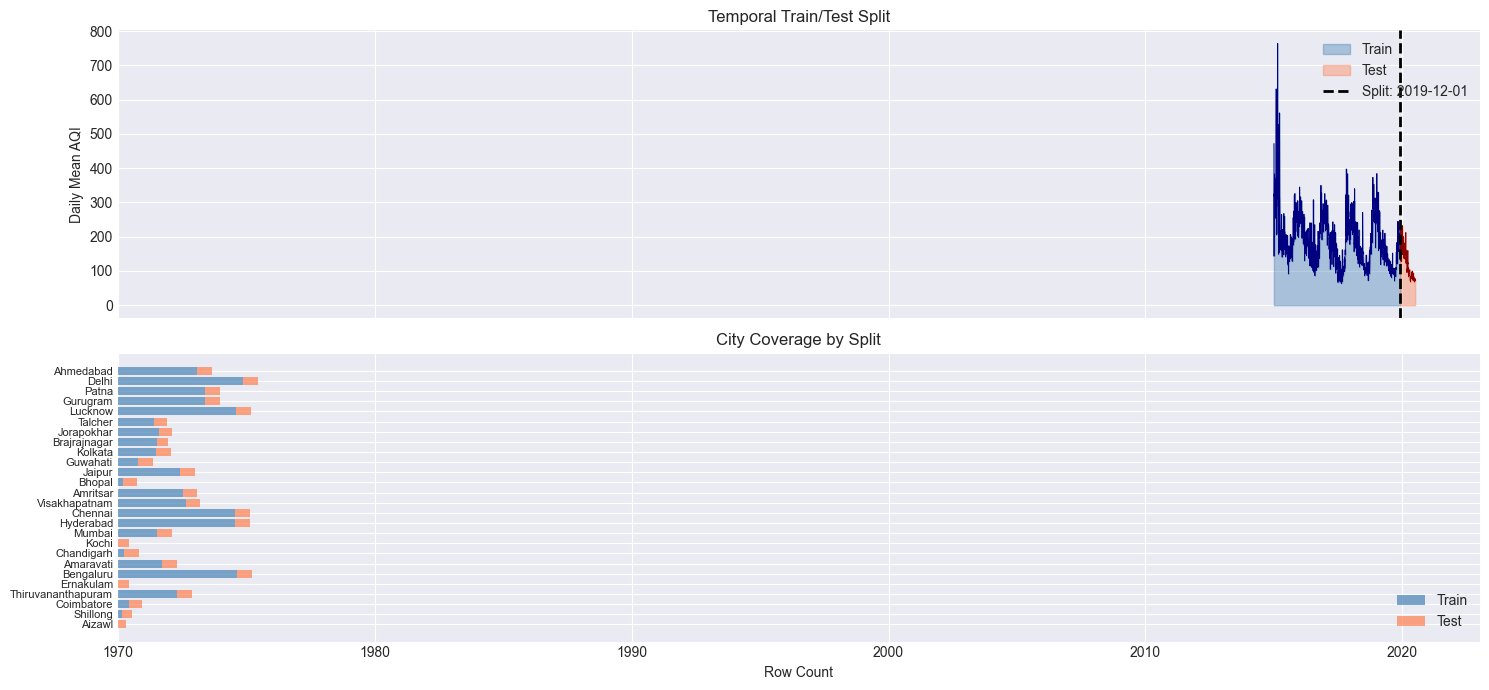

In [8]:
# Visualise the temporal split
fig, axes = plt.subplots(2, 1, figsize=(15, 7), sharex=True)

# Top: timeline coloured by split
daily = df.groupby('date').agg(mean_aqi=('aqi', 'mean'), count=('aqi', 'count')).reset_index()
train_daily = daily[daily['date'] < cutoff_date]
test_daily  = daily[daily['date'] >= cutoff_date]

axes[0].fill_between(train_daily['date'], train_daily['mean_aqi'], alpha=0.4, color='steelblue', label='Train')
axes[0].fill_between(test_daily['date'],  test_daily['mean_aqi'],  alpha=0.4, color='coral',    label='Test')
axes[0].plot(train_daily['date'], train_daily['mean_aqi'], lw=0.6, color='navy')
axes[0].plot(test_daily['date'],  test_daily['mean_aqi'],  lw=0.6, color='darkred')
axes[0].axvline(cutoff_date, color='black', ls='--', lw=2, label=f'Split: {cutoff_date.date()}')
axes[0].set(ylabel='Daily Mean AQI', title='Temporal Train/Test Split')
axes[0].legend(loc='upper right')

# Bottom: city coverage in each split
city_order = df.groupby('city')['aqi'].mean().sort_values().index
train_counts = df.loc[train_mask].groupby('city').size().reindex(city_order, fill_value=0)
test_counts  = df.loc[test_mask].groupby('city').size().reindex(city_order, fill_value=0)

y_pos = range(len(city_order))
axes[1].barh(y_pos, train_counts.values, color='steelblue', alpha=0.7, label='Train')
axes[1].barh(y_pos, test_counts.values, left=train_counts.values, color='coral', alpha=0.7, label='Test')
axes[1].set_yticks(list(y_pos))
axes[1].set_yticklabels(city_order, fontsize=8)
axes[1].set(xlabel='Row Count', title='City Coverage by Split')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

---
## 5. Feature Engineering

Features are built **within each city** to prevent cross-city leakage.

| Feature Group | Features | Rationale |
|---|---|---|
| Calendar | month, day_of_week, is_weekend, season (one-hot) | Seasonality from EDA |
| Pollutant (raw) | pm2.5, pm10, no2, so2, co, o3, no, nox, nh3, benzene, toluene, xylene | Top correlators |
| Lag features | aqi_lag1, aqi_lag7 | Yesterday & last week (autoregressive signal) |
| Rolling stats | aqi_roll7_mean, aqi_roll7_std | 7-day smoothed trend + volatility |
| City | city (one-hot) | Baseline pollution level per city |
| Missingness | *_missing flags | Sensor-offline signal |

**Lag/rolling features are computed before the split** but only using past data within each row's history (no forward-looking).

In [9]:
# --- 5a: Calendar features ---
df['month']       = df['date'].dt.month
df['day_of_week'] = df['date'].dt.dayofweek
df['is_weekend']  = (df['day_of_week'] >= 5).astype(int)

def get_season(month):
    if month in [12, 1, 2]:    return 'winter'
    if month in [3, 4, 5]:     return 'summer'
    if month in [6, 7, 8, 9]:  return 'monsoon'
    return 'post_monsoon'

df['season'] = df['month'].apply(get_season)
season_dummies = pd.get_dummies(df['season'], prefix='season', drop_first=True)
df = pd.concat([df, season_dummies], axis=1)

print('Calendar features added:', ['month', 'day_of_week', 'is_weekend', 'season'] + season_dummies.columns.tolist())

Calendar features added: ['month', 'day_of_week', 'is_weekend', 'season', 'season_post_monsoon', 'season_summer', 'season_winter']


In [10]:
# --- 5b: Lag and rolling features (per-city, shift-based — no leakage) ---
df = df.sort_values(['city', 'date']).reset_index(drop=True)

df['aqi_lag1']        = df.groupby('city')['aqi'].shift(1)
df['aqi_lag7']        = df.groupby('city')['aqi'].shift(7)
df['aqi_roll7_mean']  = df.groupby('city')['aqi'].transform(
    lambda x: x.shift(1).rolling(window=7, min_periods=3).mean()
)
df['aqi_roll7_std']   = df.groupby('city')['aqi'].transform(
    lambda x: x.shift(1).rolling(window=7, min_periods=3).std()
)

# Fill any NaN in lag/rolling features with city median (first few rows per city)
for col in ['aqi_lag1', 'aqi_lag7', 'aqi_roll7_mean', 'aqi_roll7_std']:
    df[col] = df[col].fillna(df.groupby('city')[col].transform('median'))

print('Lag/rolling features added: aqi_lag1, aqi_lag7, aqi_roll7_mean, aqi_roll7_std')
print(f'NaN remaining in lag features: {df[["aqi_lag1","aqi_lag7","aqi_roll7_mean","aqi_roll7_std"]].isna().sum().sum()}')

Lag/rolling features added: aqi_lag1, aqi_lag7, aqi_roll7_mean, aqi_roll7_std
NaN remaining in lag features: 0


In [11]:
# --- 5c: City one-hot encoding ---
city_dummies = pd.get_dummies(df['city'], prefix='city', drop_first=True)
df = pd.concat([df, city_dummies], axis=1)

print(f'City dummy columns: {city_dummies.shape[1]}')

City dummy columns: 25


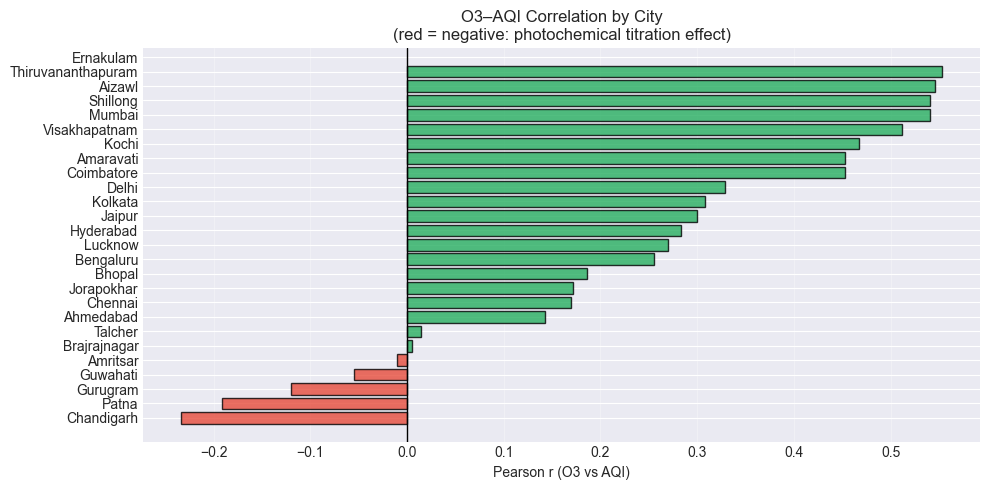


Cities with negative O3-AQI correlation: ['Chandigarh', 'Patna', 'Gurugram', 'Guwahati', 'Amritsar']
Handling: O3 kept as-is. City dummies allow the model to learn city-specific O3 behaviour.


In [12]:
# --- 5d: O3 sign-flip check — confirm it's city-dependent ---
# O3 has negative correlation with AQI in some cities (photochemical inverse relationship)
# We do NOT remove it — the model can learn city-specific behaviour via city dummies.
# Visualise to confirm the pattern.

o3_corr = df.groupby('city').apply(
    lambda g: g[['o3', 'aqi']].corr().iloc[0, 1]
).sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#e74c3c' if v < 0 else '#27ae60' for v in o3_corr.values]
ax.barh(o3_corr.index, o3_corr.values, color=colors, edgecolor='black', alpha=0.8)
ax.axvline(0, color='black', lw=1)
ax.set(xlabel='Pearson r (O3 vs AQI)', title='O3–AQI Correlation by City\n(red = negative: photochemical titration effect)')
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

neg_cities = o3_corr[o3_corr < 0].index.tolist()
print(f'\nCities with negative O3-AQI correlation: {neg_cities}')
print('Handling: O3 kept as-is. City dummies allow the model to learn city-specific O3 behaviour.')

In [13]:
# --- 5e: Final feature set summary ---
pollutant_feats = pollutant_cols  # already imputed
missing_flags   = [c for c in df.columns if c.endswith('_missing')]
calendar_feats  = ['month', 'day_of_week', 'is_weekend'] + [c for c in df.columns if c.startswith('season_')]
lag_feats       = ['aqi_lag1', 'aqi_lag7', 'aqi_roll7_mean', 'aqi_roll7_std']
city_feats      = [c for c in df.columns if c.startswith('city_')]

FEATURE_COLS = pollutant_feats + missing_flags + calendar_feats + lag_feats + city_feats
TARGET_RAW   = 'aqi'
TARGET_LOG   = 'aqi_log'

print(f'Total features: {len(FEATURE_COLS)}')
print(f'  Pollutants:    {len(pollutant_feats)}')
print(f'  Missing flags: {len(missing_flags)}')
print(f'  Calendar:      {len(calendar_feats)}')
print(f'  Lag/Rolling:   {len(lag_feats)}')
print(f'  City dummies:  {len(city_feats)}')
print(f'\nTargets: {TARGET_RAW} (eval scale), {TARGET_LOG} (train scale)')

Total features: 59
  Pollutants:    12
  Missing flags: 12
  Calendar:      6
  Lag/Rolling:   4
  City dummies:  25

Targets: aqi (eval scale), aqi_log (train scale)


---
## 6. Metric Selection

We report **three metrics on the original AQI scale** (after inverting log predictions):

| Metric | Why |
|---|---|
| **RMSE** | Penalises large errors (important for severe-AQI days) |
| **MAE** | Interpretable as average absolute error in AQI units |
| **R²** | Proportion of variance explained |

We also break down MAE **per AQI category** (Good / Satisfactory / Moderate / Poor / Very Poor / Severe)
to check whether the model degrades on extreme days.

A naive **persistence baseline** (predict yesterday's AQI) is computed first as the floor.

In [14]:
# --- 6a: Define AQI category bins ---
AQI_BINS   = [0, 50, 100, 200, 300, 400, 5000]
AQI_LABELS = ['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']

def categorise_aqi(series):
    return pd.cut(series, bins=AQI_BINS, labels=AQI_LABELS)

# --- 6b: Evaluation function ---
def evaluate(y_true, y_pred, label='Model'):
    """Full evaluation: RMSE, MAE, R² overall + MAE per category."""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    
    print(f'\n--- {label} ---')
    print(f'  RMSE : {rmse:.2f}')
    print(f'  MAE  : {mae:.2f}')
    print(f'  R²   : {r2:.4f}')
    
    # Per-category MAE
    cats = categorise_aqi(y_true)
    print(f'\n  MAE by AQI category:')
    for cat in AQI_LABELS:
        mask = cats == cat
        if mask.sum() > 0:
            cat_mae = mean_absolute_error(y_true[mask], y_pred[mask])
            print(f'    {cat:>14s}: MAE = {cat_mae:7.2f}  (n={mask.sum():,})')
    
    return {'label': label, 'RMSE': rmse, 'MAE': mae, 'R2': r2}

print('Evaluation function defined. Metrics: RMSE, MAE, R² + per-category MAE.')

Evaluation function defined. Metrics: RMSE, MAE, R² + per-category MAE.


---
## 7. Baseline Models

Two baselines before the Ridge regression:
1. **Persistence baseline** — predict yesterday's AQI (no model, just lag1)
2. **Ridge regression** — regularised linear model on the full feature set, trained on log1p(AQI)

In [15]:
# --- 7a: Persistence baseline (predict yesterday's AQI) ---
# For test rows, aqi_lag1 is computed from train data only (no leakage)

test_df = df.loc[test_mask].copy()
train_df = df.loc[train_mask].copy()

persistence_preds = test_df['aqi_lag1'].values
persistence_true  = test_df['aqi'].values

results = []
results.append(evaluate(persistence_true, persistence_preds, label='Persistence (lag-1)'))


--- Persistence (lag-1) ---
  RMSE : 44.34
  MAE  : 21.52
  R²   : 0.7594

  MAE by AQI category:
              Good: MAE =    7.01  (n=535)
      Satisfactory: MAE =   10.82  (n=2,116)
          Moderate: MAE =   24.58  (n=1,746)
              Poor: MAE =   50.29  (n=406)
         Very Poor: MAE =   41.80  (n=236)
            Severe: MAE =  162.36  (n=61)


In [16]:
# --- 7b: Ridge regression on log1p(AQI) ---

# DIAGNOSTIC: find any remaining NaNs in features before fitting
train_check = train_df[FEATURE_COLS]
nan_cols = train_check.columns[train_check.isna().any()].tolist()
if nan_cols:
    print(f'WARNING — {len(nan_cols)} columns still contain NaN:')
    print(train_check[nan_cols].isna().sum())
    print()

# SAFETY NET: fill remaining NaNs
# - Dummy/flag columns (binary) -> 0
# - Continuous columns -> train median (computed here, applied to both sets)
dummy_cols = [c for c in FEATURE_COLS if c.startswith('city_') or c.startswith('season_') or c.endswith('_missing') or c in ['is_weekend']]
cont_cols  = [c for c in FEATURE_COLS if c not in dummy_cols]

# Fill dummies with 0
for col in dummy_cols:
    train_df[col] = train_df[col].fillna(0)
    test_df[col]  = test_df[col].fillna(0)

# Fill continuous features with train-set median (no leakage)
train_medians = train_df[cont_cols].median()
for col in cont_cols:
    train_df[col] = train_df[col].fillna(train_medians[col])
    test_df[col]  = test_df[col].fillna(train_medians[col])

# Verify clean
assert train_df[FEATURE_COLS].isna().sum().sum() == 0, 'Train still has NaNs!'
assert test_df[FEATURE_COLS].isna().sum().sum()  == 0, 'Test still has NaNs!'
print('All NaNs resolved. Proceeding with Ridge fit.')

X_train = train_df[FEATURE_COLS].values
y_train = train_df[TARGET_LOG].values   # log1p(AQI)

X_test  = test_df[FEATURE_COLS].values
y_test_log = test_df[TARGET_LOG].values
y_test_raw = test_df[TARGET_RAW].values  # original scale for evaluation

# Standardise features
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# Fit Ridge (alpha=1.0 default — can tune later)
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_s, y_train)

# Predict in log space, invert to raw AQI
y_pred_log = ridge.predict(X_test_s)
y_pred_raw = np.expm1(y_pred_log)           # invert log1p
y_pred_raw = np.clip(y_pred_raw, 0, None)   # AQI cannot be negative

results.append(evaluate(y_test_raw, y_pred_raw, label='Ridge (log1p target, alpha=1.0)'))

WARNING — 6 columns still contain NaN:
pm10       1679
nox         578
nh3        1127
benzene    1490
toluene    2893
xylene     9551
dtype: int64

All NaNs resolved. Proceeding with Ridge fit.

--- Ridge (log1p target, alpha=1.0) ---
  RMSE : 43.77
  MAE  : 26.85
  R²   : 0.7655

  MAE by AQI category:
              Good: MAE =   30.38  (n=535)
      Satisfactory: MAE =   19.88  (n=2,116)
          Moderate: MAE =   18.08  (n=1,746)
              Poor: MAE =   51.72  (n=406)
         Very Poor: MAE =   58.29  (n=236)
            Severe: MAE =  201.50  (n=61)


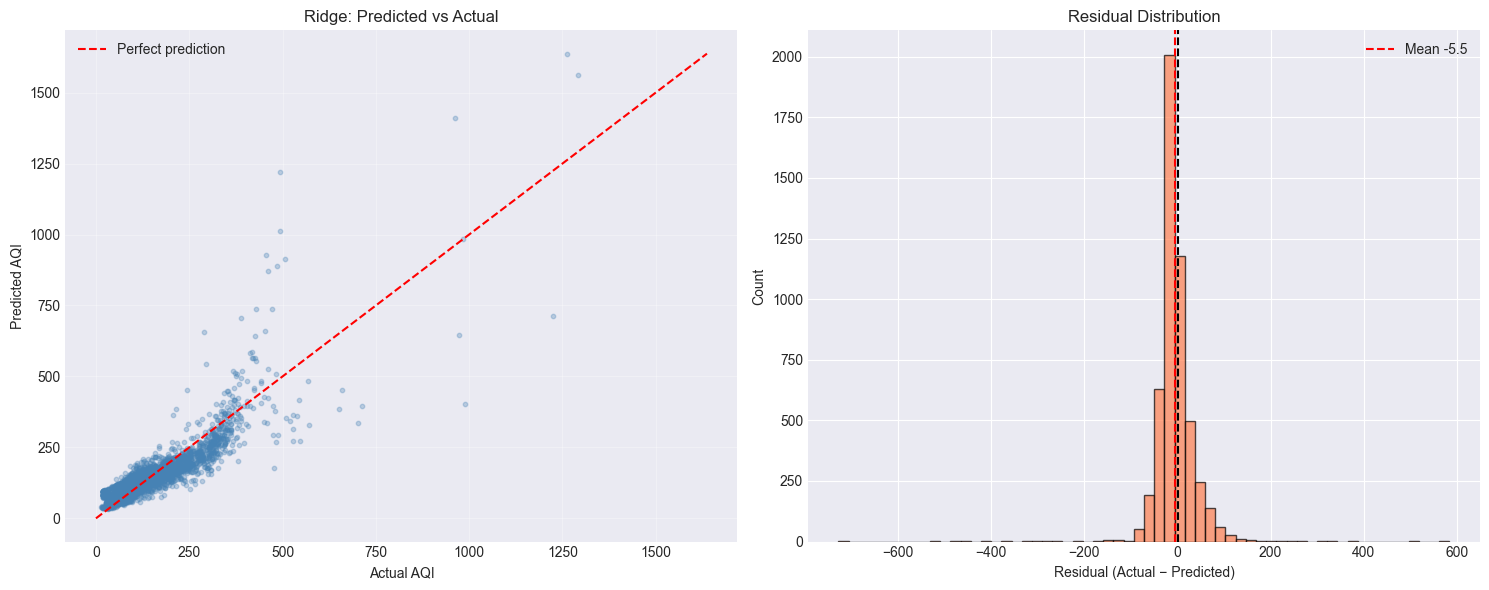

In [17]:
# --- 7c: Visualise predictions vs actuals ---
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Scatter: predicted vs actual
axes[0].scatter(y_test_raw, y_pred_raw, alpha=0.3, s=10, color='steelblue')
lim_max = max(y_test_raw.max(), y_pred_raw.max())
axes[0].plot([0, lim_max], [0, lim_max], 'r--', lw=1.5, label='Perfect prediction')
axes[0].set(xlabel='Actual AQI', ylabel='Predicted AQI', title='Ridge: Predicted vs Actual')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Residual distribution
residuals = y_test_raw - y_pred_raw
axes[1].hist(residuals, bins=60, color='coral', edgecolor='black', alpha=0.7)
axes[1].axvline(0, color='black', ls='--', lw=1.5)
axes[1].axvline(residuals.mean(), color='red', ls='--', label=f'Mean {residuals.mean():.1f}')
axes[1].set(xlabel='Residual (Actual − Predicted)', ylabel='Count',
            title='Residual Distribution')
axes[1].legend()

plt.tight_layout()
plt.show()

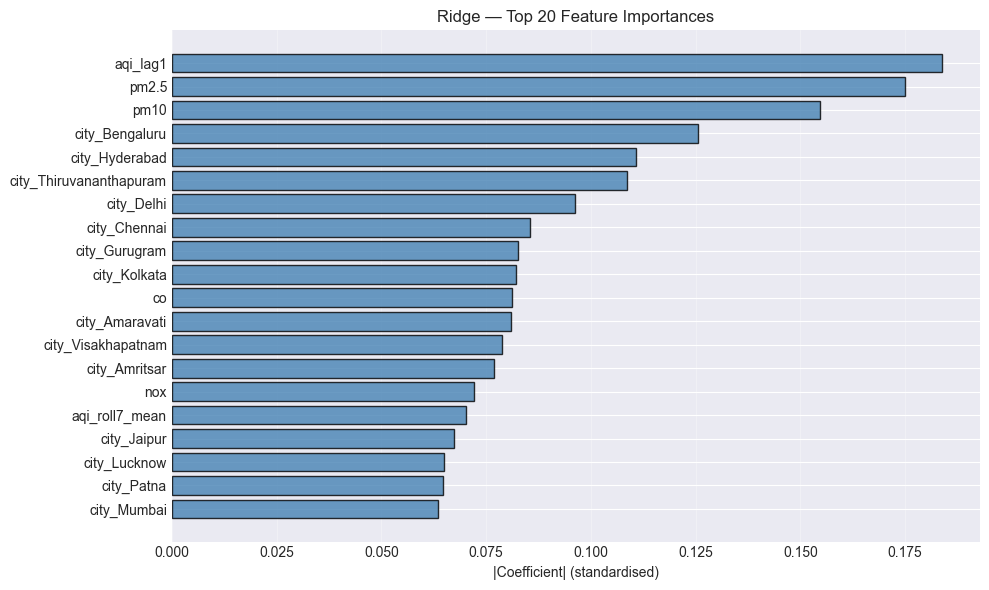

In [20]:
# --- 7d: Feature importance (Ridge coefficients on standardised features) ---
importance = pd.Series(np.abs(ridge.coef_), index=FEATURE_COLS).sort_values(ascending=False)

# Show top 20
top_n = 20
fig, ax = plt.subplots(figsize=(10, 6))
top_imp = importance.head(top_n)
ax.barh(top_imp.index[::-1], top_imp.values[::-1], color='steelblue', edgecolor='black', alpha=0.8)
ax.set(xlabel='|Coefficient| (standardised)', title=f'Ridge — Top {top_n} Feature Importances')
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

In [21]:
# --- 7e: Summary table of all baselines ---
summary = pd.DataFrame(results)
summary = summary.set_index('label')
print('\n' + '='*60)
print('  BASELINE SUMMARY (all metrics on original AQI scale)')
print('='*60)
print(summary.round(3).to_string())
print('='*60)
print('\nNext steps for development stage:')
print('  • Try Random Forest / Gradient Boosting (handle nonlinearity)')
print('  • Tune lag window lengths and rolling periods')
print('  • Add pollutant lag features (not just AQI lags)')
print('  • Neural network (LSTM or 1D-CNN) on the time series')
print('  • Per-city model ensemble vs single global model comparison')


  BASELINE SUMMARY (all metrics on original AQI scale)
                                   RMSE     MAE     R2
label                                                 
Persistence (lag-1)              44.336  21.520  0.759
Ridge (log1p target, alpha=1.0)  43.768  26.848  0.765

Next steps for development stage:
  • Try Random Forest / Gradient Boosting (handle nonlinearity)
  • Tune lag window lengths and rolling periods
  • Add pollutant lag features (not just AQI lags)
  • Neural network (LSTM or 1D-CNN) on the time series
  • Per-city model ensemble vs single global model comparison


---
## Decision Log — Summary

| # | Question | Decision | Justification |
|---|---|---|---|
| 1 | Scope | All 26 cities, city as one-hot feature | Title says India NCR; richer training set |
| 2 | Missing data | Drop rows where AQI is NaN; per-city median imputation for pollutants; add `_missing` flags | Target must be known; median robust to skew; flags preserve sensor-offline signal |
| 3 | Target transform | Train on log1p(AQI), evaluate on raw scale | Reduces skewness from ~4.4 to <1; standard for right-skewed regression |
| 4 | Train/test split | Temporal cutoff at month boundary (~80/20) | Prevents future-data leakage; mimics real deployment |
| 5 | Features | Pollutants + lags + rolling + calendar + city dummies + missing flags | Covers autocorrelation, seasonality, spatial baseline, sensor quality |
| 6 | Metrics | RMSE, MAE, R² overall + MAE per AQI category | RMSE weights severe days; per-category check for tail performance |
| 7 | O3 sign flip | Keep O3; let city dummies handle city-specific behaviour | Chemically valid; removing it loses information |
| 8 | Baseline | Persistence (lag-1) + Ridge regression | Persistence = naive floor; Ridge = simple linear ceiling before tree/NN models |